In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [2]:
df=pd.read_csv('CLEANED_Algerian_dataset.csv',)

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [5]:
## drop month day and year
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [6]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [7]:
df['Classes'].value_counts()

Classes
fire             131
not fire          96
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [8]:
## Encoding
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [9]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [10]:
df['Classes'].value_counts()

Classes
1    137
0    101
Name: count, dtype: int64

In [11]:
## Independent and dependent feature
X= df.drop('FWI', axis=1)
y=df['FWI']

In [12]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [13]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

In [14]:
#Train Test Split


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.25, random_state=42)

In [17]:
X_train.shape, X_test.shape

((178, 11), (60, 11))

In [18]:
d=X_train.corr()

<Axes: >

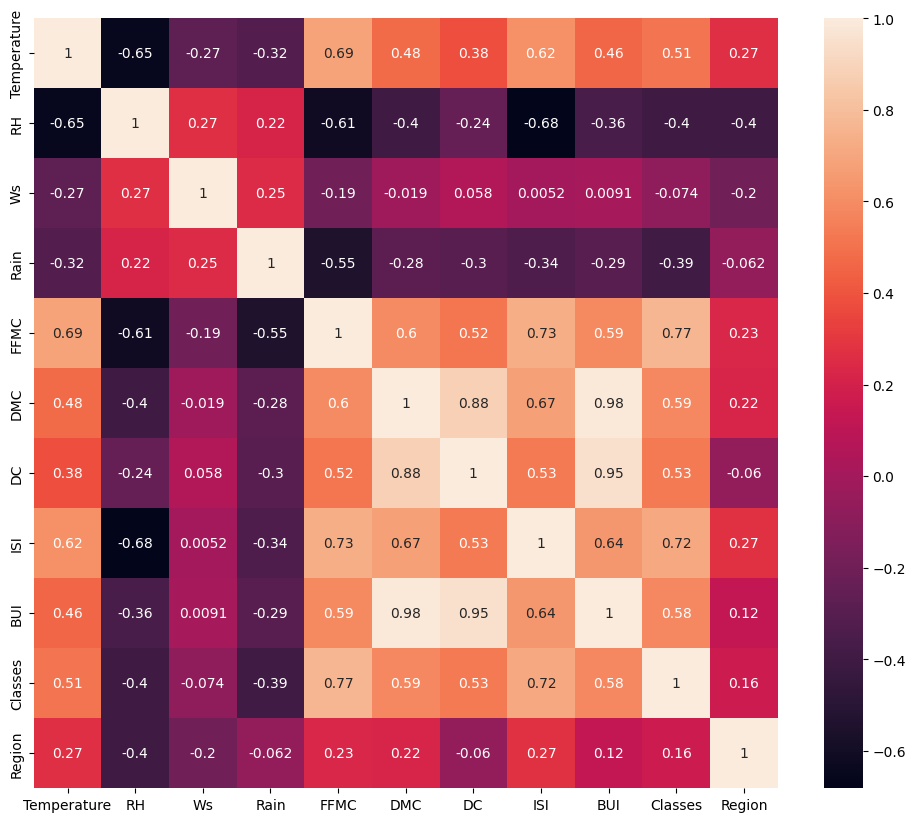

In [22]:
#  check for multi colinearity
plt.figure(figsize=(12,10))
sns.heatmap(d, annot=True)

In [23]:
def correlation(dataset, threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])> threshold:
                colname= corr_matrix.columns[i]
                col_corr.add(colname)
                
    return col_corr


In [26]:
# threshold setup
corr_featu=correlation(X_train, 0.85)

In [27]:
#  drop the features when corr> 0.85
X_train.drop(corr_featu, axis=1, inplace=True)
X_test.drop(corr_featu, axis=1, inplace=True)
X_train.shape, X_test.shape

((178, 9), (60, 9))

## Feature Scaling and Standardization

In [28]:
#  Feature Scaling/ Standardization

In [29]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [30]:
X_train_scaled

array([[-1.38986482, -0.23441195,  0.92748603, ..., -0.55566943,
        -1.14528962,  1.03429563],
       [-0.03945031, -1.02292208, -0.573355  , ..., -0.70052053,
        -1.14528962, -0.96684156],
       [-0.03945031,  0.81693488, -0.573355  , ...,  0.12030236,
         0.87314159, -0.96684156],
       ...,
       [-1.93003062,  0.88264406,  0.55227577, ..., -1.08679013,
        -1.14528962, -0.96684156],
       [ 1.85113   , -1.94285056,  0.55227577, ...,  3.01732434,
         0.87314159,  1.03429563],
       [-0.57961611,  0.94835324,  2.05311681, ..., -0.86951348,
        -1.14528962, -0.96684156]], shape=(178, 9))

Text(0.5, 1.0, 'X_train after scaling')

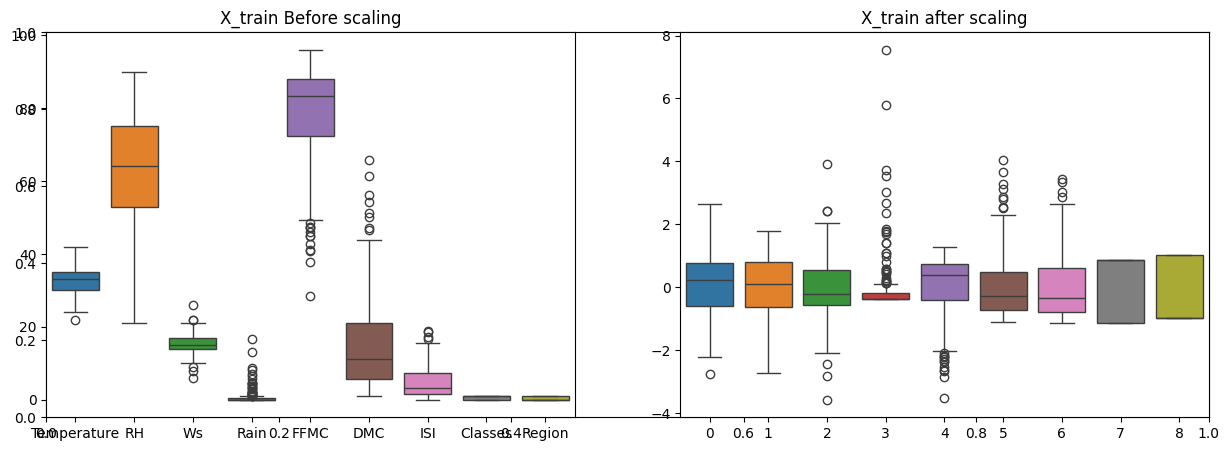

In [33]:
#box plot to undersatnd effect of standard scaler

plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train Before scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train after scaling')

## Linear Regression Value

In [42]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
# documentation

In [43]:
linreg=LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred= linreg.predict(X_test_scaled)
mae= mean_absolute_error(y_test, y_pred)
score= r2_score(y_test, y_pred)
print("Mean Absolute error", mae)
print("R2 Score", score)

Mean Absolute error 0.6872025610368863
R2 Score 0.9809714597688967


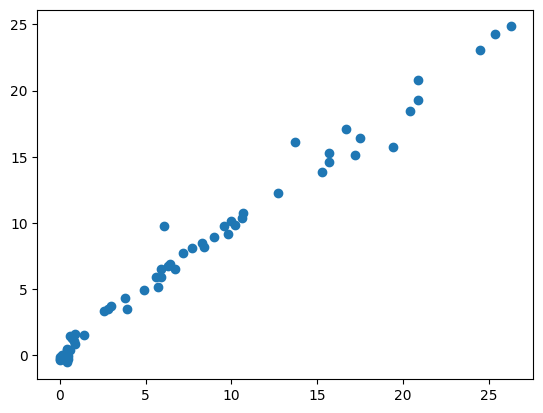

In [44]:
plt.scatter(y_test, y_pred)

Mean Absolute error 1.3056366111415876
R2 Score 0.9413422474204282


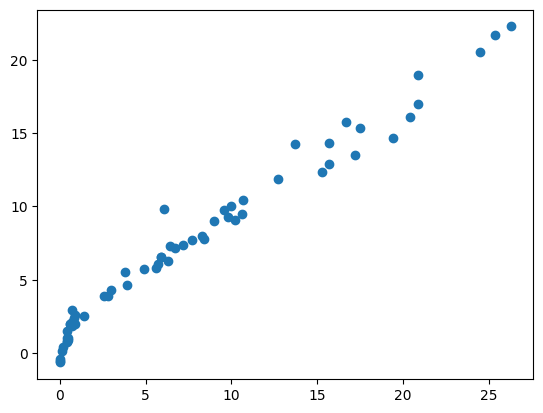

In [45]:
## Lasso Regression

lasso=Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred= lasso.predict(X_test_scaled)
mae= mean_absolute_error(y_test, y_pred)
score= r2_score(y_test, y_pred)
print("Mean Absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test, y_pred)

Mean Absolute error 0.713164382108186
R2 Score 0.9801729713006023


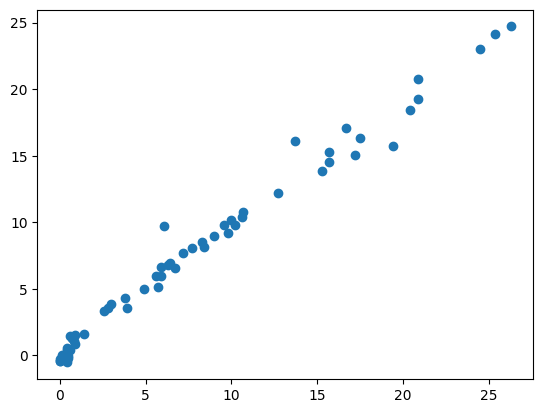

In [46]:
## Ridge Regression

ridge= Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred= ridge.predict(X_test_scaled)
mae= mean_absolute_error(y_test, y_pred)
score= r2_score(y_test, y_pred)
print("Mean Absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test, y_pred)

## Elastic Net

In [47]:
from sklearn.linear_model import ElasticNet

Mean Absolute error 2.006938040491046
R2 Score 0.8723912368107576


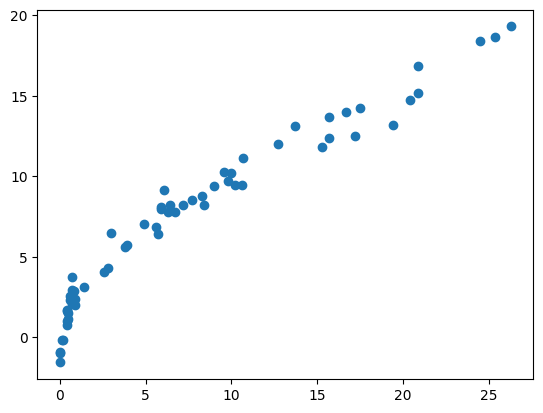

In [48]:


elastic=ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred= elastic.predict(X_test_scaled)
mae= mean_absolute_error(y_test, y_pred)
score= r2_score(y_test, y_pred)
print("Mean Absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test, y_pred)

## Cross Validation

In [50]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV()
lassocv.fit(X_train_scaled, y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [53]:
lassocv.mse_path_

array([[41.86250072, 47.65928136, 28.76601878, 72.32410638, 77.77318338],
       [37.10436074, 43.06189194, 25.08018479, 72.32410638, 77.77318338],
       [32.76007455, 39.00109926, 21.65377685, 64.3514189 , 74.80950734],
       [28.95928017, 34.40377627, 18.73974617, 56.9767046 , 66.18244073],
       [25.63257405, 30.34009338, 16.26718882, 50.51483217, 58.73700007],
       [22.71977853, 26.78778908, 14.17431449, 44.84994911, 51.84822235],
       [20.16821115, 23.68195937, 12.4075852 , 39.88151718, 44.84864305],
       [17.93204591, 20.96530739, 10.92128915, 35.52148827, 38.78604179],
       [15.97124198, 18.58817746,  9.67533071, 31.6932282 , 33.53607749],
       [14.25120209, 16.5073119 ,  8.63525502, 28.32973084, 28.99229862],
       [12.74145684, 14.68502237,  7.77130748, 25.37308698, 25.06075966],
       [11.41554129, 13.08820975,  7.05780704, 22.77224343, 21.66033995],
       [10.25037518, 11.68880677,  6.47236249, 20.48283186, 18.72057796],
       [ 9.22582631, 10.46157191,  5.9

Mean Absolute error : 0.7186242062871487 
 R2 score is 0.9799200340329807


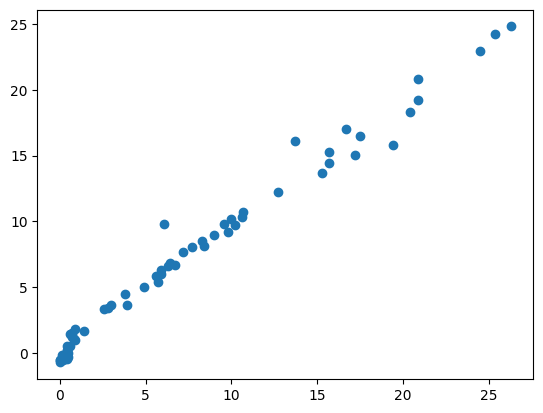

In [56]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f"Mean Absolute error : {mae} \n R2 score is {score}") 

In [57]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV()

Mean Absolute error : 0.7131643821081717 
 R2 score is 0.9801729713006121


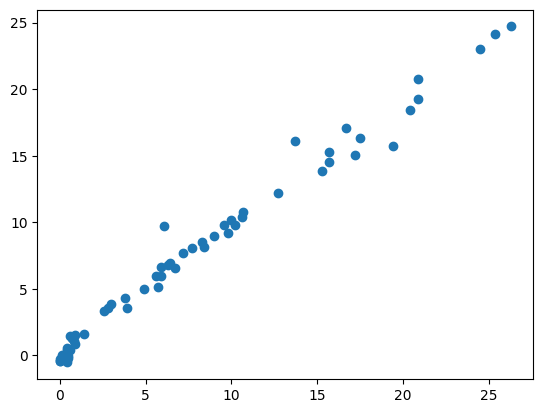

In [58]:
ridgecv.fit(X_train_scaled, y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f"Mean Absolute error : {mae} \n R2 score is {score}") 

In [59]:
from sklearn.linear_model import ElasticNetCV
elasticCV=ElasticNetCV()

Mean Absolute error : 0.763239959846167 
 R2 score is 0.9785243814255558


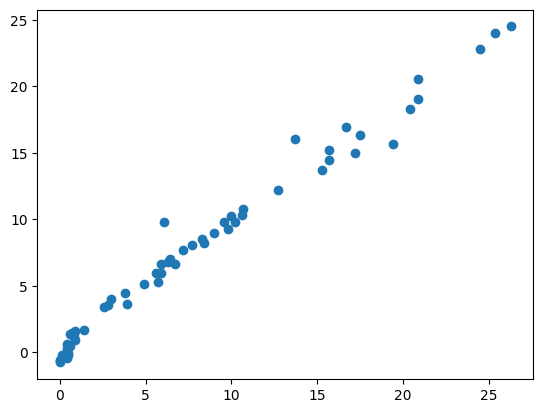

In [60]:
elasticCV.fit(X_train_scaled, y_train)
y_pred=elasticCV.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f"Mean Absolute error : {mae} \n R2 score is {score}") 